# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [2]:
import numpy as np
import pandas as pd

sms_data = pd.read_csv('data/spam_or_not_spam.csv')
sms_data.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [3]:
#Сгруппируем данные по принцупу не спам-0 и спам-1
sms_data.groupby('label').count()

,email
label,
0,2500
1,499


<Axes: title={'center': 'Круговая диаграмма распеределения спам и не спам писем'}, ylabel='label'>

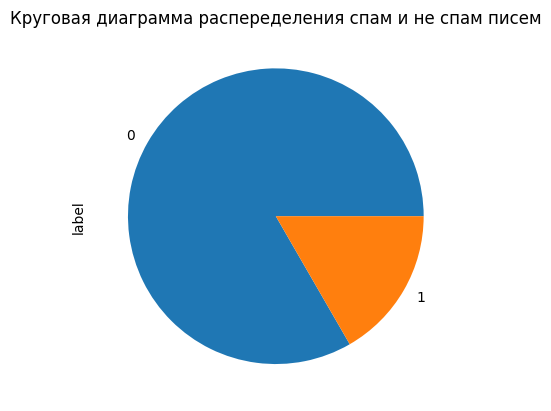

In [4]:
sms_data.groupby('label')['label'].count().plot(kind='pie',title='Круговая диаграмма распеределения спам и не спам писем')

## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [6]:
df_filled = sms_data.fillna(value=np.nan)

#Удалим строки с пропущенными значениями
df_filled= df_filled.dropna(
how='any',
axis=0
)

Переводим данные в векторный вид:

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_filled["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [8]:
print('В нашем наборе данных',X.shape[1], 'признаков')

В нашем наборе данных 34116 признаков


## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [9]:
y = df_filled["label"]

#Отобразим размер признаков и целевой перемонной
print(X.shape, y.shape)

(2999, 34116) (2999,)


Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [10]:
X_train, X_test, y_train, y_test= train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [11]:
print('Cреднее значение целевой переменной по тестовой выборке:', round(y_train.mean(),3))

Cреднее значение целевой переменной по тестовой выборке: 0.166


## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [12]:
#Обучим байесовский классификатор MultinomialNB,т.к он работает с категориальными признаками, 
# текстами и несбалансированными выборками;
clf_M_NB = MultinomialNB(alpha = 0.01)
clf_M_NB.fit(X_train, y_train)

y_test_pred = clf_M_NB.predict(X_test)

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [13]:
from sklearn import metrics
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print(f"Accuracy: {round(accuracy_score(y_test, y_test_pred),3)}") 
print(f"Precision: {round(precision_score(y_test, y_test_pred),3)}")
print(f"Recall: {round(recall_score(y_test, y_test_pred),3)}")
print(f"f1-Мера: {round(f1_score(y_test, y_test_pred),3)}")

Accuracy: 0.988
Precision: 0.992
Recall: 0.936
f1-Мера: 0.963


In [14]:
#Обучим байесовский классификатор ComplementNB - улучшенная версия MultinomialNB, стабильно 
#показывает более высокое качество в задачах классификации текстов;

from sklearn.naive_bayes import ComplementNB

clf_C_NB = ComplementNB(alpha = 0.01)
clf_C_NB.fit(X_train, y_train)

y_test_pred = clf_C_NB.predict(X_test)

print(f"Accuracy: {round(accuracy_score(y_test, y_test_pred),3)}") 
print(f"Precision: {round(precision_score(y_test, y_test_pred),3)}")
print(f"Recall: {round(recall_score(y_test, y_test_pred),3)}")
print(f"f1-Мера: {round(f1_score(y_test, y_test_pred),3)}")

Accuracy: 0.989
Precision: 0.992
Recall: 0.944
f1-Мера: 0.967


Нарисуйте ROC-кривую:

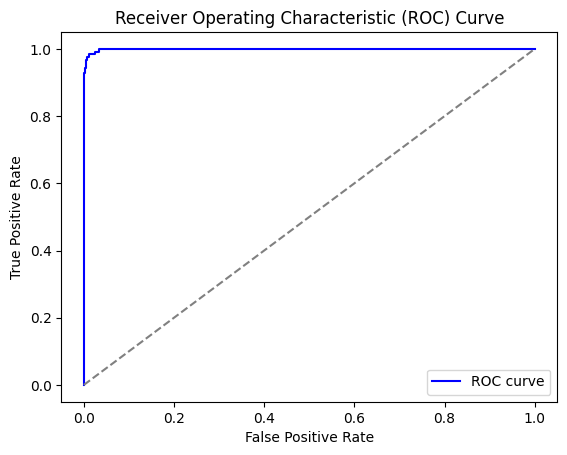

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Получение предсказанных вероятностей для байесовского классификатора MultinomialNB
y_probs = clf_M_NB.predict_proba(X_test)[:, 1]

# Вычисление TPR и FPR
fpr, tpr, _ = roc_curve(y_test, y_probs)

# Построение ROC-кривой
plt.figure()
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [18]:
'''Дополнительно сделаем расчет AUC (Area Under the Curve) AUC (Area Under the Curve) —  
это метрика, которая оценивает качество модели. AUC равна вероятности того, что случайно 
выбранное положительное наблюдение будет оценено выше случайно выбранного отрицательного.'''

from sklearn.metrics import roc_auc_score

# Вычисление AUC
auc = roc_auc_score(y_test, y_probs)
print(f'AUC: {auc:.2f}')

AUC: 1.00


*расчет AUC показал высокое качество модели*

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [19]:
from sklearn import model_selection
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

param = {'alpha':[0.01,0.1, 0.2, 0.3, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5, 10, 15, 20]}
grid_search = GridSearchCV(
    scoring='accuracy',
    estimator=clf_C_NB,
    param_grid=param,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
best_params = grid_search.best_params_

clf_M_NB = MultinomialNB(alpha=grid_search.best_params_['alpha'])
clf_M_NB.fit(X_train, y_train)

y_test_pred = clf_M_NB.predict(X_test)

cv_results = cross_validate(clf_M_NB, X_test, y_test_pred, scoring='accuracy', cv=5, return_train_score=True)

{'alpha': 0.1}


In [20]:
clf_M_NB = MultinomialNB(alpha = 0.1)

clf_M_NB.fit(X_train, y_train)
y_test_pred = clf_M_NB.predict(X_test)

print(f"Accuracy: {round(accuracy_score(y_test, y_test_pred),3)}") 
print(f"Precision: {round(precision_score(y_test, y_test_pred),3)}")
print(f"Recall: {round(recall_score(y_test, y_test_pred),3)}")
print(f"f1-Мера: {round(f1_score(y_test, y_test_pred),3)}")
print(metrics.classification_report(y_test, y_test_pred))

Accuracy: 0.995
Precision: 1.0
Recall: 0.968
f1-Мера: 0.984
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       625
           1       1.00      0.97      0.98       125

    accuracy                           0.99       750
   macro avg       1.00      0.98      0.99       750
weighted avg       0.99      0.99      0.99       750



*Вывод: параметр alpha влияет на качество модели. Наилучшее качество модели достигается на параметре alpha =0.1. После обучения модели с оптимальным параметром значение всех метрик улучшилось*

<p style="border:3px black solid; text-align: left; padding: 10px">В этом задании получилось решить достаточно сложную задачу классификации текстовых данных. Можно использовать такой алгоритм действий для определения тональности текстов, выявления фейковых новостей и любых других задач, где необходимо использовать тексты как признаки.